# Schedulable Parameters

We optimise the 2‑D Rastrigin function with a GA while **two** parameters
change over time:
1. **Mutation scale** – a `LinearSchedule` from 0.5 to 0.01.
2. **Mutation probability** – a `StepSchedule` that starts high (0.8) for
    exploration, then drops to 0.1 after 40 % of the generations for
    exploitation.

We’ll run the algorithm manually and plot the schedules together with the
best fitness.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Rastrigin
from metaheuristic_designer.parameter_schedules import (
    LinearSchedule,
    StepSchedule,
)

rng = mhd.check_rng(42)

## 1. Objective function

In [2]:
DIM = 2
objfunc = Rastrigin(DIM, mode="min")

## 2. Schedules

- `mutation_scale`: linearly from 0.5 → 0.01
- `mutation_prob`: 0.8 until progress 0.4, then 0.1

In [3]:
mutation_scale = LinearSchedule(init_value=0.5, final_value=0.001)
mutation_prob = StepSchedule({0.0: 0.8, 0.4: 0.1})

Check schedules for different progres values

In [4]:
print("Mutation scale at 0, 0.5, 1.0:", mutation_scale(0.0), mutation_scale(0.5), mutation_scale(1.0))
print("Mutation prob  at 0, 0.3, 0.5:", mutation_prob(0.0), mutation_prob(0.3), mutation_prob(0.5))

Mutation scale at 0, 0.5, 1.0: 0.5 0.2505 0.001
Mutation prob  at 0, 0.3, 0.5: 0.8 0.8 0.1


## 3. Operator with scheduled parameters

We decompose the operator into a `BranchOperator` that decides *whether* to
mutate (prob) and a composite that applies mutation (scale).

The library’s `BranchOperator` already accepts a probability as a `p` parameter.
We can replace that probability with our schedule.  Mutation scale is the `F`
parameter of the Gaussian mutation.

In [5]:
mut_op = mhd.operators.create_operator(
    "mutation.gaussian_mutation",
    N=1,
    F=mutation_scale,  # scheduled strength
    rng=rng,
)

# BranchOperator: with probability = mutation_prob, apply mut_op; otherwise do nothing
evolve_op = mhd.operators.BranchOperator(
    [mut_op, mhd.operators.NullOperator()],
    method="Random",
    p=mutation_prob,  # scheduled probability
    rng=rng,
)

## 4. Fixed selections

In [6]:
survivor_sel = mhd.survivor_selection.create_survivor_selection(
    "one_to_one",
    rng=rng,
)

## 5. Build strategy and algorithm

In [7]:
strategy = mhd.strategies.PopulationBasedStrategy(
    initializer=mhd.initializers.UniformInitializer(DIM, -5.12, 5.12, population_size=30, rng=rng),
    operator=evolve_op,
    survivor_sel=survivor_sel,
    rng=rng,
)
algo = mhd.algorithms.Algorithm(
    objfunc,
    strategy,
    max_iterations=100,
    stop_condition_str="max_iterations",
    reporter="tqdm",
)

## 6. Run manually, recording schedule values

After each step, we retrieve the current parameter values from the
operators we defined earlier.

In [8]:
scale_history, prob_history, fit_history = [], [], []
population = algo.initialize()
algo.reporter.log_init(algo)
for gen in range(100):
    population = algo.step(population)  # Run one step of the algorithm

    scale_history.append(mut_op.get_params()["F"])
    prob_history.append(evolve_op.get_params()["p"])
algo.reporter.log_end(algo)

population = algo.population

  0%|          |   0% [00:00<?, ?it/s]

  0%|          |   0% [00:00<?, ?it/s]

## 7. Visualize everything

In [9]:
solution, fitness = population.best_solution()
print(f"Best fitness: {fitness}")
print(f"Best solution: {solution}")

Best fitness: 0.31073688718620573
Best solution: [-0.03963641  0.00181485]


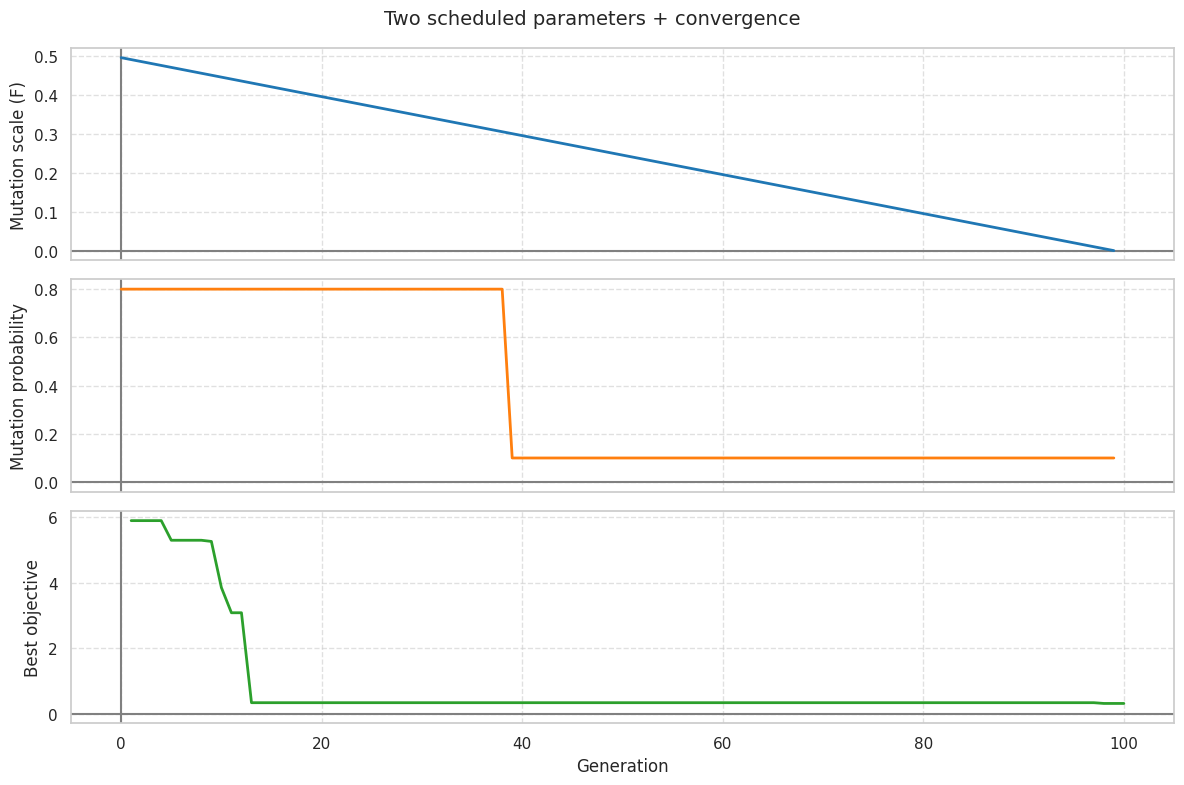

In [10]:
# After the loop,
history_df = algo.history_tracker.to_pandas()

# Then in the plotting cell:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 8))

ax1.plot(scale_history, color="tab:blue", linewidth=2, zorder=10)
ax1.set_ylabel("Mutation scale (F)")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.axhline(0, color="grey")
ax1.axvline(0, color="grey")

ax2.plot(prob_history, color="tab:orange", linewidth=2, zorder=10)
ax2.set_ylabel("Mutation probability")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.axhline(0, color="grey")
ax2.axvline(0, color="grey")

# New seaborn-style convergence on ax3
sns.lineplot(data=history_df, x="iteration", y="best_objective", ax=ax3, linewidth=2, color="tab:green", zorder=10)
ax3.set_xlabel("Generation", fontsize=12)
ax3.set_ylabel("Best objective", fontsize=12)
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.axhline(0, color="grey")
ax3.axvline(0, color="grey")

plt.suptitle("Two scheduled parameters + convergence", fontsize=14)
plt.tight_layout()
plt.show()

This example shows how easy it is to combine multiple schedules.
You can replace the step schedule with a `LogisticSchedule` for smooth
transitions, or even wrap a `RandomSchedule` for stochastic exploration.